In [3]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.decomposition import NMF

output_dir = Path("outputs_text_analysis")
output_dir.mkdir(exist_ok=True)

data_path = Path("data/bitcoin_tweet.parquet")
text_col = "text"

df = pd.read_parquet(data_path)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (632179, 13)
Columns: ['user_name', 'user_created', 'user_followers', 'user_friends', 'user_verified', 'date', 'text', 'hashtags', 'mentions', 'account_age_days', 'age_bucket', 'url_count', 'text_clean']


In [4]:
custom_stopwords = {
    "rt", "amp", "https", "http", "www", "com",
    "username", "user", "users", "tweet", "tweets", "twitter",
    "follow", "followers", "link", "join", "tips",
    "btc", "bitcoin", "crypto", "cryptocurrency",
    "just", "like", "time", "people", "don", "good", "going", "think",
    "know", "make", "need", "new", "really", "want", "way", "day",
    "today", "thing", "things", "let", "look", "still", "much",
    "many", "say", "said", "year", "years", "week", "weeks",
    "great", "right", "best", "big", "soon", "use", "better",
    "seasonaltokens", "cryptomining", "cyclicalinvesting", "cyclicallnvesting",
    "betfurysuccess", "cashback", "rank", "play", "higher", "staking",
    "seriously", "doing"
}

stopwords = set(ENGLISH_STOP_WORDS).union(custom_stopwords)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [
        word for word in text.split()
        if word not in stopwords and len(word) > 2
    ]

    return " ".join(tokens)

df["clean_text"] = df[text_col].apply(clean_text)
df_clean = df[df["clean_text"].str.len() > 2].copy()

print("Original rows:", len(df))
print("Rows after cleaning:", len(df_clean))

df_clean[[text_col, "clean_text"]].head(10)

Original rows: 632179
Rows after cleaning: 627360


,text,clean_text
16,@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - ...,amazing impressed project hopefully event comm...
24,@iamDonaldYusuf @yuzomausman @aproko_doctor No...,fud sub wan risk buy prices imo
25,I personally ignore weekend moves and chill wi...,personally ignore weekend moves chill family
31,Move Digital Energy Through Cyber Space. #Bitc...,digital energy cyber space
51,"1/2 End of shitcoin season, lasted even longer...",end shitcoin season lasted longer expected fro...
59,More traditional market content going on the T...,traditional market content tube content youtub...
61,Less than 10hours to save #Bitcoin weekly cand...,hours save weekly candle
87,@JasonPLowery Real Question?\n\nWouldn’t this ...,real question wouldn mean nations warfare long...
89,@JoshuaBarbin1 @danheld How do you get more de...,decentralized network tens thousands nodes cou...
110,#11MINUTES #BTC #CRYPTO\nThis project is a pro...,minutes project profitable project investors i...


In [5]:
random_state = 42
sample_size = 200000

if len(df_clean) > sample_size:
    topic_df = df_clean.sample(
        n=sample_size,
        random_state=random_state
    ).copy()
else:
    topic_df = df_clean.copy()

print("Total cleaned tweets:", len(df_clean))
print("Rows used for topic modelling:", len(topic_df))

topic_df[["clean_text"]].head(10)

Total cleaned tweets: 627360
Rows used for topic modelling: 200000


,clean_text
2707681,human emotion market sentiment maddest witness
499782,initiate operation safe dailyclose
3120463,shouting lets goes
3498940,discovered ago
2566819,missed sol luna rocket train leaving inch catc...
909625,hodler send address
887944,investment properties change dependent systems...
1578396,muscky worldwide community try help launched t...
4047720,bought dip happy red friday
1366696,sense shorting mstr short short run won surprised


In [7]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words=list(stopwords),
    max_df=0.90,
    min_df=10,
    max_features=8000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(topic_df["clean_text"])
feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Number of terms/features:", tfidf_matrix.shape[1])

TF-IDF matrix shape: (200000, 8000)
Number of terms/features: 8000


Testing 3 topics
Testing 4 topics
Testing 5 topics
Testing 6 topics
Testing 7 topics
Testing 8 topics


,num_topics,reconstruction_error
0,3,443.031768
1,4,442.311596
2,5,441.626169
3,6,440.985601
4,7,440.365390
5,8,439.808190


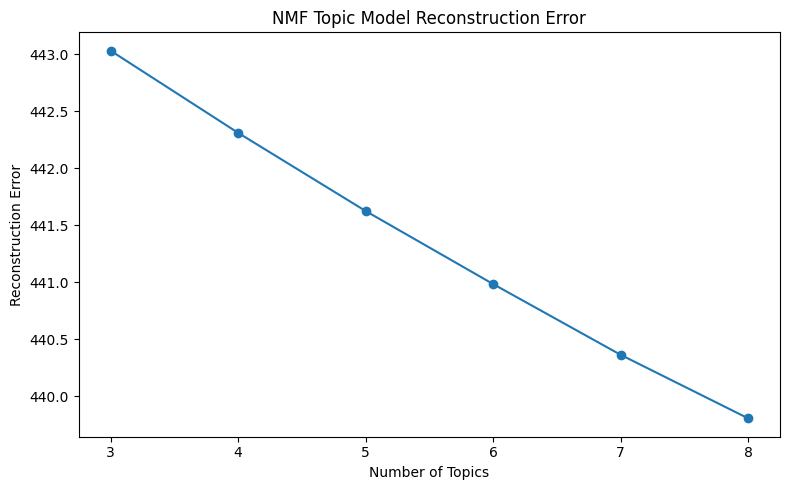

In [8]:
topic_range = range(3, 9)
topic_scores = []

for n_topics in topic_range:
    print("Testing", n_topics, "topics")

    nmf_model = NMF(
        n_components=n_topics,
        random_state=random_state,
        init="nndsvda",
        max_iter=400
    )

    nmf_model.fit(tfidf_matrix)

    topic_scores.append({
        "num_topics": n_topics,
        "reconstruction_error": nmf_model.reconstruction_err_
    })

topic_scores_df = pd.DataFrame(topic_scores)
display(topic_scores_df)

topic_scores_df.to_csv(
    output_dir / "nmf_topic_number_scores.csv",
    index=False
)

plt.figure(figsize=(8, 5))
plt.plot(
    topic_scores_df["num_topics"],
    topic_scores_df["reconstruction_error"],
    marker="o"
)
plt.xlabel("Number of Topics")
plt.ylabel("Reconstruction Error")
plt.title("NMF Topic Model Reconstruction Error")
plt.tight_layout()
plt.savefig(output_dir / "nmf_reconstruction_error.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
n_topics_final = 5

final_nmf_model = NMF(
    n_components=n_topics_final,
    random_state=random_state,
    init="nndsvda",
    max_iter=400
)

topic_matrix = final_nmf_model.fit_transform(tfidf_matrix)
topic_word_matrix = final_nmf_model.components_

topic_df["dominant_topic"] = topic_matrix.argmax(axis=1)
topic_df["topic_strength"] = topic_matrix.max(axis=1)

print("Topic counts:")
print(topic_df["dominant_topic"].value_counts().sort_index())

Topic counts:
dominant_topic
0     13410
1    139591
2     15647
3     17885
4     13467
Name: count, dtype: int64


In [10]:
def show_topics(model, feature_names, top_n=15):
    topic_rows = []

    for topic_idx, topic_weights in enumerate(model.components_):
        top_indices = topic_weights.argsort()[::-1][:top_n]
        top_terms = [feature_names[i] for i in top_indices]

        topic_rows.append({
            "topic": topic_idx,
            "top_terms": ", ".join(top_terms)
        })

    return pd.DataFrame(topic_rows)

topics = show_topics(final_nmf_model, feature_names, top_n=15)

pd.set_option("display.max_colwidth", None)
display(topics)

topics.to_csv(output_dir / "nmf_topics_top_terms.csv", index=False)

,topic,top_terms
0,0,"buy, dip, sell, buy dip, buy buy, hodl, sell buy, buy sell, buy hodl, wait, hold, buy hold, did buy, did, money buy"
1,1,"money, price, buying, long, world, gold, value, fiat, bought, term, short, bullish, understand, inflation, does"
2,2,"project, future, team, bsc, bnb, hope, strong, success, project project, binance, successful, project future, blockchain, believe, support"
3,3,"eth, ethereum, bnb, doge, ada, xrp, eth bnb, sol, nft, ethereum eth, eth eth, eth ethereum, shib, dogecoin, bnb eth"
4,4,"market, bear, bear market, bull, bull market, cap, market cap, run, bull run, bullish, stock, stock market, end, ethereum, markets"


In [11]:
topic_labels = {
    0: "Buying, selling and trading behaviour",
    1: "Bitcoin as money and store of value",
    2: "Crypto projects and future expectations",
    3: "Ethereum and altcoin discussion",
    4: "Market cycles and price movement"
}

topic_df["topic_label"] = topic_df["dominant_topic"].map(topic_labels)
topics["topic_label"] = topics["topic"].map(topic_labels)

display(topics[["topic", "topic_label", "top_terms"]])

topics[["topic", "topic_label", "top_terms"]].to_csv(
    output_dir / "nmf_topics_labelled.csv",
    index=False
)

,topic,topic_label,top_terms
0,0,"Buying, selling and trading behaviour","buy, dip, sell, buy dip, buy buy, hodl, sell buy, buy sell, buy hodl, wait, hold, buy hold, did buy, did, money buy"
1,1,Bitcoin as money and store of value,"money, price, buying, long, world, gold, value, fiat, bought, term, short, bullish, understand, inflation, does"
2,2,Crypto projects and future expectations,"project, future, team, bsc, bnb, hope, strong, success, project project, binance, successful, project future, blockchain, believe, support"
3,3,Ethereum and altcoin discussion,"eth, ethereum, bnb, doge, ada, xrp, eth bnb, sol, nft, ethereum eth, eth eth, eth ethereum, shib, dogecoin, bnb eth"
4,4,Market cycles and price movement,"market, bear, bear market, bull, bull market, cap, market cap, run, bull run, bullish, stock, stock market, end, ethereum, markets"


,topic_label,tweet_count,percentage
0,Bitcoin as money and store of value,139591,69.80
1,Ethereum and altcoin discussion,17885,8.94
2,Crypto projects and future expectations,15647,7.82
3,Market cycles and price movement,13467,6.73
4,"Buying, selling and trading behaviour",13410,6.70


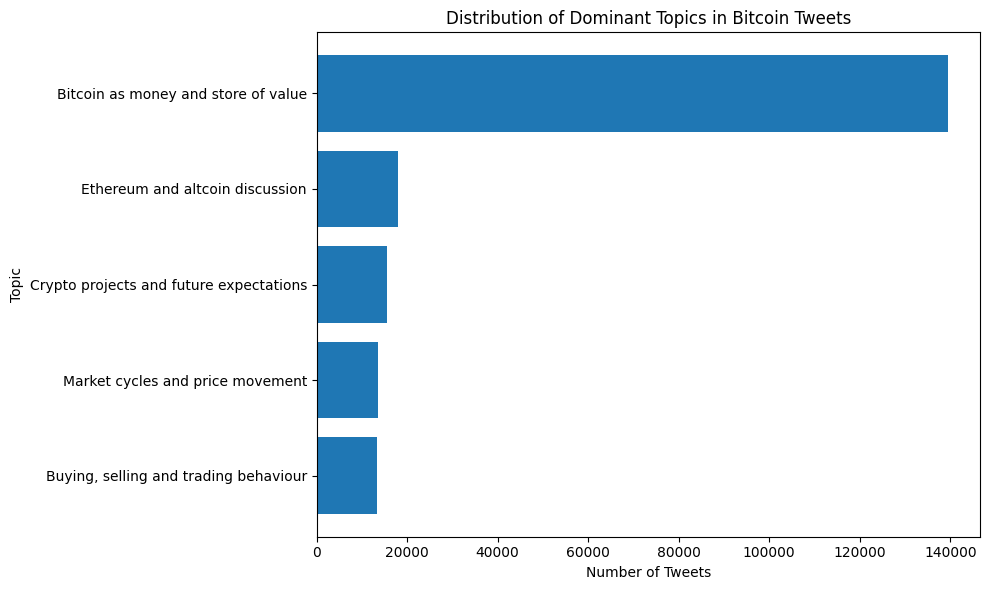

In [12]:
topic_distribution = (
    topic_df["topic_label"]
    .value_counts()
    .rename_axis("topic_label")
    .reset_index(name="tweet_count")
)

topic_distribution["percentage"] = (
    topic_distribution["tweet_count"] / topic_distribution["tweet_count"].sum() * 100
).round(2)

display(topic_distribution)

topic_distribution.to_csv(
    output_dir / "topic_distribution_sample.csv",
    index=False
)

plt.figure(figsize=(10, 6))
plt.barh(
    topic_distribution["topic_label"][::-1],
    topic_distribution["tweet_count"][::-1]
)
plt.xlabel("Number of Tweets")
plt.ylabel("Topic")
plt.title("Distribution of Dominant Topics in Bitcoin Tweets")
plt.tight_layout()
plt.savefig(output_dir / "topic_distribution_sample.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
representative_tweets = []

for topic_num in sorted(topic_df["dominant_topic"].unique()):
    subset = (
        topic_df[topic_df["dominant_topic"] == topic_num]
        .sort_values("topic_strength", ascending=False)
        .head(5)
    )

    for _, row in subset.iterrows():
        representative_tweets.append({
            "topic": topic_num,
            "topic_label": row["topic_label"],
            "topic_strength": round(row["topic_strength"], 4),
            "original_text": row[text_col],
            "clean_text": row["clean_text"]
        })

representative_tweets_df = pd.DataFrame(representative_tweets)

display(representative_tweets_df)

representative_tweets_df.to_csv(
    output_dir / "representative_tweets_by_topic.csv",
    index=False
)

,topic,topic_label,topic_strength,original_text,clean_text
0,0,"Buying, selling and trading behaviour",0.1478,I will buy 100.000 Btc more in 7 day. #Bitcoin,buy
1,0,"Buying, selling and trading behaviour",0.1478,@BIGTY_24 That’s more #Bitcoin I can buy,buy
2,0,"Buying, selling and trading behaviour",0.1478,"@Bitcoinomist Buy #btc around 20k, then keep it for 4-5 years",buy
3,0,"Buying, selling and trading behaviour",0.1478,If you could go back in time.\n\nWhat would you buy?\n#Bitcoin #Crypto,buy
4,0,"Buying, selling and trading behaviour",0.1478,@CryptoWhale you can buy time with #bitcoin,buy
5,1,Bitcoin as money and store of value,0.0715,@justin_Munford @CryptoA40672341 $wluna is best opportunity for make money . price going down because of #BTC,wluna opportunity money price
6,1,Bitcoin as money and store of value,0.0704,@KyleLDavies Too much money. Too few #BTC,money
7,1,Bitcoin as money and store of value,0.0704,"@saylor @IIICapital No way, \n#btc is more than a money",money
8,1,Bitcoin as money and store of value,0.0704,@TheMoonCarl whichever I make money 🤑 #Bitcoin,whichever money
9,1,Bitcoin as money and store of value,0.0704,@MartiniGuyYT But what if you don't have money to #BTC now?,money


In [17]:
full_tfidf_matrix = tfidf_vectorizer.transform(df_clean["clean_text"])
full_topic_matrix = final_nmf_model.transform(full_tfidf_matrix)

df_clean["dominant_topic"] = full_topic_matrix.argmax(axis=1)
df_clean["topic_strength"] = full_topic_matrix.max(axis=1)

topic_strength_sum = full_topic_matrix.sum(axis=1)

df_clean["topic_confidence"] = [
    max_score / total_score if total_score != 0 else 0
    for max_score, total_score
    in zip(full_topic_matrix.max(axis=1), topic_strength_sum)
]

df_clean["topic_label"] = df_clean["dominant_topic"].map(topic_labels)
df_clean["text_clean"] = df_clean["clean_text"]

print("Topics applied to full dataset.")
print("Rows:", len(df_clean))
print("Columns added: dominant_topic, topic_label, topic_strength, topic_confidence")

Topics applied to full dataset.
Rows: 627360
Columns added: dominant_topic, topic_label, topic_strength, topic_confidence


,topic,topic_label,tweet_count,percentage
0,0,"Buying, selling and trading behaviour",41742,6.65
1,1,Bitcoin as money and store of value,437662,69.76
2,2,Crypto projects and future expectations,49425,7.88
3,3,Ethereum and altcoin discussion,56299,8.97
4,4,Market cycles and price movement,42232,6.73


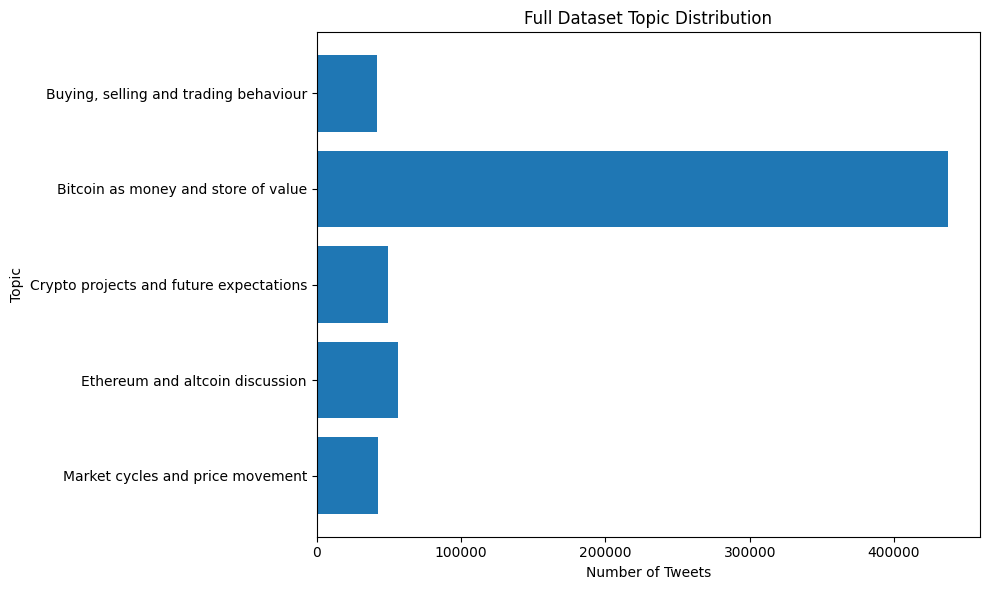

In [15]:
full_topic_summary = (
    df_clean["topic_label"]
    .value_counts()
    .rename_axis("topic_label")
    .reset_index(name="tweet_count")
)

full_topic_summary["percentage"] = (
    full_topic_summary["tweet_count"] / full_topic_summary["tweet_count"].sum() * 100
).round(2)

topic_number_lookup = (
    df_clean[["dominant_topic", "topic_label"]]
    .drop_duplicates()
    .rename(columns={"dominant_topic": "topic"})
)

full_topic_summary = (
    full_topic_summary
    .merge(topic_number_lookup, on="topic_label", how="left")
    [["topic", "topic_label", "tweet_count", "percentage"]]
    .sort_values("topic")
    .reset_index(drop=True)
)

display(full_topic_summary)

full_topic_summary.to_csv(
    output_dir / "full_dataset_topic_summary.csv",
    index=False
)

plt.figure(figsize=(10, 6))
plt.barh(
    full_topic_summary["topic_label"][::-1],
    full_topic_summary["tweet_count"][::-1]
)
plt.xlabel("Number of Tweets")
plt.ylabel("Topic")
plt.title("Full Dataset Topic Distribution")
plt.tight_layout()
plt.savefig(output_dir / "full_dataset_topic_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
export_columns = [
    "user_name",
    "user_created",
    "user_followers",
    "user_friends",
    "user_verified",
    "date",
    "text",
    "text_clean",
    "hashtags",
    "mentions",
    "account_age_days",
    "dominant_topic",
    "topic_label",
    "topic_strength",
    "topic_confidence"
]

export_columns = [col for col in export_columns if col in df_clean.columns]

bitcoin_tweet_with_topics = df_clean[export_columns].copy()

output_file = Path("data/bitcoin_tweet_with_topics.parquet")
bitcoin_tweet_with_topics.to_parquet(output_file, index=False)

print("Export complete.")
print("Saved file:", output_file)
print("Rows exported:", len(bitcoin_tweet_with_topics))
print("Columns exported:")
print(bitcoin_tweet_with_topics.columns.tolist())

Export complete.
Saved file: data\bitcoin_tweet_with_topics.parquet
Rows exported: 627360
Columns exported:
['user_name', 'user_created', 'user_followers', 'user_friends', 'user_verified', 'date', 'text', 'text_clean', 'hashtags', 'mentions', 'account_age_days', 'dominant_topic', 'topic_label', 'topic_strength', 'topic_confidence']
